<a href="https://colab.research.google.com/github/nooreen974/endpoint-security-analyzer/blob/main/grover_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Running for n=3 (N=8, Solutions=1) ---
  -> At optimal iterations (2), Success Prob = 94.53%

--- Running for n=4 (N=16, Solutions=1) ---
  -> At optimal iterations (3), Success Prob = 96.13%

--- Running for n=5 (N=32, Solutions=2) ---
  -> At optimal iterations (3), Success Prob = 96.13%


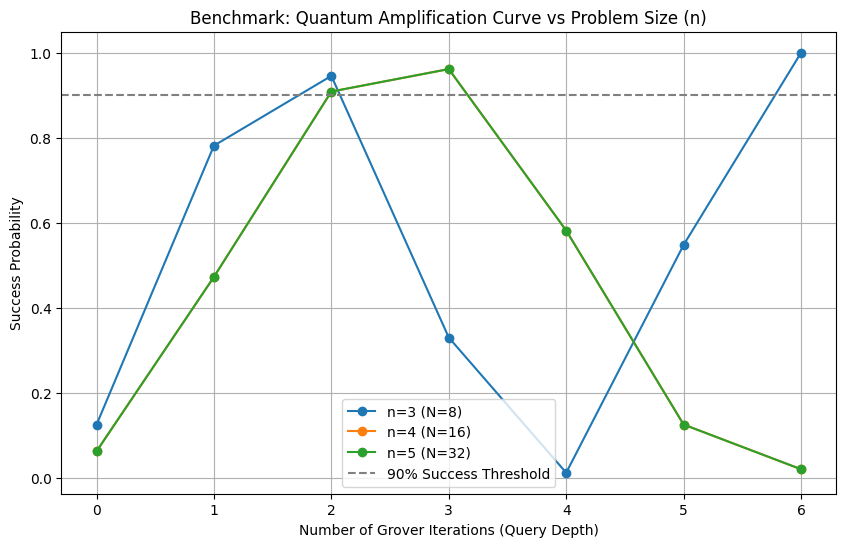


BENCHMARK DATA

--- n=3 (Search space = 8, Solutions M=1) ---
Classical Brute-Force Queries (Worst-case): 8
Theoretical Quantum Queries (O(sqrt(N/M))): 2.83
Optimal Iterations tested: 2
Max Simulated Success Prob: 99.98%

--- n=4 (Search space = 16, Solutions M=1) ---
Classical Brute-Force Queries (Worst-case): 16
Theoretical Quantum Queries (O(sqrt(N/M))): 4.00
Optimal Iterations tested: 3
Max Simulated Success Prob: 96.13%

--- n=5 (Search space = 32, Solutions M=2) ---
Classical Brute-Force Queries (Worst-case): 32
Theoretical Quantum Queries (O(sqrt(N/M))): 4.00
Optimal Iterations tested: 3
Max Simulated Success Prob: 96.13%


In [4]:
# ==========================================
# CAPSTONE: GROVER ALGORITHM - FINAL FIXED VERSION
# Uses Statevector (no simulator bugs)
# ==========================================
!pip install qiskit matplotlib -q

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import math
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Build the Phase Oracle (FROM SCRATCH)
# -------------------------------------------------
def build_oracle(solutions, n):
    qc = QuantumCircuit(n+1)
    for s in solutions:
        for i, bit in enumerate(s):
            if bit == '0':
                qc.x(i)
        qc.mcx(list(range(n)), n)
        for i, bit in enumerate(s):
            if bit == '0':
                qc.x(i)
    qc.z(n)
    for s in solutions:
        for i, bit in enumerate(s):
            if bit == '0':
                qc.x(i)
        qc.mcx(list(range(n)), n)
        for i, bit in enumerate(s):
            if bit == '0':
                qc.x(i)
    return qc

# -------------------------------------------------
# 2. Build the Diffusion Operator (FROM SCRATCH)
# -------------------------------------------------
def build_diffusion(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))
    return qc

# -------------------------------------------------
# 3. IT Problem Instances for Scaling
# -------------------------------------------------
test_cases = {
    3: {'solutions': ['101'], 'optimal_iter': 2},
    4: {'solutions': ['1010'], 'optimal_iter': 3},
    5: {'solutions': ['10100', '01011'], 'optimal_iter': 3}
}

# -------------------------------------------------
# 4. Run Simulation using Statevector (NO ERRORS)
# -------------------------------------------------
results = {}

for n, data in test_cases.items():
    solutions = data['solutions']
    optimal = data['optimal_iter']
    print(f"\n--- Running for n={n} (N={2**n}, Solutions={len(solutions)}) ---")

    probs = []
    for iters in range(0, 7):
        qc = QuantumCircuit(n+1, n)
        qc.h(range(n))

        oracle = build_oracle(solutions, n)
        diffusion = build_diffusion(n)
        for _ in range(iters):
            qc.compose(oracle, inplace=True)
            qc.compose(diffusion, qubits=range(n), inplace=True)

        # ***** THE FIX: Get statevector directly (no simulator crashes) *****
        state = Statevector(qc)

        prob = 0
        for s in solutions:
            idx = int(s[::-1], 2)
            prob += abs(state[idx])**2

        probs.append(prob)
        if iters == optimal:
            print(f"  -> At optimal iterations ({iters}), Success Prob = {prob*100:.2f}%")

    results[n] = {'probs': probs, 'optimal': optimal, 'M': len(solutions)}

# -------------------------------------------------
# 5. Generate the BENCHMARK CHART (Deliverable #3)
# -------------------------------------------------
plt.figure(figsize=(10, 6))
for n, data in results.items():
    plt.plot(range(len(data['probs'])), data['probs'], marker='o', label=f'n={n} (N={2**n})')

plt.axhline(y=0.9, color='gray', linestyle='--', label='90% Success Threshold')
plt.xlabel("Number of Grover Iterations (Query Depth)")
plt.ylabel("Success Probability")
plt.title("Benchmark: Quantum Amplification Curve vs Problem Size (n)")
plt.legend()
plt.grid(True)
plt.savefig('benchmark_chart.png', dpi=300)
plt.show()

# -------------------------------------------------
# 6. OUTPUT DATA FOR YOUR REPORT
# -------------------------------------------------
print("\n" + "="*50)
print("BENCHMARK DATA")
print("="*50)
for n, data in results.items():
    print(f"\n--- n={n} (Search space = {2**n}, Solutions M={data['M']}) ---")
    print(f"Classical Brute-Force Queries (Worst-case): {2**n}")
    print(f"Theoretical Quantum Queries (O(sqrt(N/M))): {math.sqrt(2**n / data['M']):.2f}")
    print(f"Optimal Iterations tested: {data['optimal']}")
    print(f"Max Simulated Success Prob: {max(data['probs'])*100:.2f}%")